<a href="https://colab.research.google.com/github/Chockalingam-M/Deep-Learning-for-Computer_Vision/blob/main/Stand_alone_word_embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Stand-Alone word Embedding


In [3]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
import pandas as pd
import matplotlib.pyplot as plt

keras.utils.set_random_seed(42)

In [5]:
def plot_loss_curves(history):
  plt.clf()
  history_dict = history.history
  loss_values = history_dict["loss"]
  val_loss_values = history_dict["val_loss"]
  epochs = range(1, len(loss_values) + 1)
  plt.plot(epochs, loss_values, "bo", label="Training loss")
  plt.plot(epochs, val_loss_values, "b", label="Validation loss")
  plt.title("Training and validation loss")
  plt.xlabel("Epochs")
  plt.ylabel("Loss")
  plt.legend()
  plt.show()

def plot_acc_curves(history):
  plt.clf()
  history_dict = history.history
  acc = history_dict["accuracy"]
  val_acc = history_dict["val_accuracy"]
  epochs = range(1, len(acc) + 1)
  plt.plot(epochs, acc, "bo", label="Training acc")
  plt.plot(epochs, val_acc, "b", label="Validation acc")
  plt.title("Training and validation accuracy")
  plt.xlabel("Epochs")
  plt.ylabel("Accuracy")
  plt.legend()
  plt.show()

In [6]:
train_url = "https://www.dropbox.com/scl/fi/ito6bnl2yaf1uw0uqibzf/lyric_genre_train.csv?rlkey=04dkn5un2djza8x0bdmfnlw3u&st=y47qh8i4&dl=1"
val_url = "https://www.dropbox.com/scl/fi/xmywjzqsaa8n5sn1bs0t9/lyric_genre_val.csv?rlkey=hggbeo0s1iaxjpa6z80429xl9&st=6i7d8eau&dl=1"
test_url = "https://www.dropbox.com/scl/fi/fnocl69w9ojs9s5zb0xvf/lyric_genre_test.csv?rlkey=z4hjopw7vaihoh948cbb5mvdp&st=xwond7dp&dl=1"

train_df = pd.read_csv(train_url)
val_df = pd.read_csv(val_url)
test_df = pd.read_csv(test_url)

print(f"""
Train samples: {train_df.shape[0]}
Validation samples: {val_df.shape[0]}
Test samples: {test_df.shape[0]}
""")


Train samples: 48991
Validation samples: 16331
Test samples: 21774



In [7]:
# Let's one-hot-encode the target
y_train = pd.get_dummies(train_df['Genre']).to_numpy()
y_val = pd.get_dummies(val_df['Genre']).to_numpy()
y_test = pd.get_dummies(test_df['Genre']).to_numpy()

In [8]:
!wget http://nlp.stanford.edu/data/glove.6B.zip

--2026-07-19 08:47:52--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-07-19 08:47:52--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-07-19 08:47:52--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

In [9]:
!unzip -q glove.6B.zip

In [16]:
! head -1 /content/glove.6B.100d.txt

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062


In [21]:
embedding_dim = 100
path_to_glove_file = f"glove.6B.{embedding_dim}d.txt"

embeddings_index = {}
with open(path_to_glove_file) as f:
    for line in f:
        word, coefs = line.split(maxsplit=1)
        coefs = np.fromstring(coefs, "f", sep=" ")
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")

Found 400000 word vectors.


In [22]:
embeddings_index["movie"]

array([ 0.38251  ,  0.14821  ,  0.60601  , -0.51533  ,  0.43992  ,
        0.061053 , -0.62716  , -0.025385 ,  0.1643   , -0.22101  ,
        0.14423  , -0.37213  , -0.21683  , -0.08895  ,  0.097904 ,
        0.6561   ,  0.64455  ,  0.47698  ,  0.83849  ,  1.6486   ,
        0.88922  , -0.1181   , -0.012465 , -0.52082  ,  0.77854  ,
        0.48723  , -0.014991 , -0.14127  , -0.34747  , -0.29595  ,
        0.1028   ,  0.57191  , -0.045594 ,  0.026443 ,  0.53816  ,
        0.32257  ,  0.40788  , -0.043599 , -0.146    , -0.48346  ,
        0.32036  ,  0.55086  , -0.76259  ,  0.43269  ,  0.61753  ,
       -0.36503  , -0.60599  , -0.79615  ,  0.3929   , -0.23668  ,
       -0.34719  , -0.61201  ,  0.54747  ,  0.94812  ,  0.20941  ,
       -2.7771   , -0.6022   ,  0.8495   ,  1.2549   ,  0.017893 ,
       -0.041901 ,  2.1147   , -0.026618 , -0.28104  ,  0.68124  ,
       -0.14165  ,  0.99249  ,  0.49879  , -0.67538  ,  0.6417   ,
        0.42303  , -0.27913  ,  0.063403 ,  0.68909  , -0.3618

In [37]:
embeddings_index["done"]

array([-2.9780e-01,  3.1147e-01, -1.4937e-01, -2.8128e-01, -1.6966e-01,
       -1.6878e-01, -1.6187e-01,  5.5923e-01,  3.4954e-02, -2.6216e-02,
        4.2287e-01,  2.6724e-02,  4.9660e-01, -9.0910e-02, -5.4288e-01,
       -3.2794e-01, -2.6140e-01,  5.7559e-01, -6.3756e-01,  5.9604e-01,
       -1.6490e-02,  2.5744e-01, -2.8617e-01, -6.3665e-01, -2.3149e-01,
       -2.2021e-02, -2.8631e-01, -6.0359e-01, -8.6679e-02, -3.7368e-01,
       -1.7426e-01,  7.6331e-01,  5.9010e-02,  1.9120e-01, -7.3460e-02,
        3.3733e-01, -4.9396e-01, -2.0621e-01, -2.2396e-01, -4.3866e-01,
       -2.7371e-01,  1.5695e-01, -1.2503e-01, -5.1089e-02, -7.5960e-01,
       -1.6716e-01,  3.5914e-01, -7.1649e-01, -3.4082e-01, -1.2409e+00,
        3.9102e-02, -1.3331e-01, -5.7205e-02,  1.0074e+00, -3.9901e-01,
       -2.0914e+00, -1.9794e-01,  1.4871e-01,  1.1303e+00,  3.8766e-01,
       -2.5686e-01,  1.1938e+00, -4.8125e-01, -5.9394e-02,  9.0870e-01,
        2.2843e-01,  5.3237e-01,  3.1132e-01, -1.4168e-01,  6.73

In [38]:
max_length = 300 #90% of songs
max_tokens = 5000

text_vectorization = keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=max_length,
)

In [39]:
text_vectorization.adapt(train_df['Lyric'])

In [42]:
text_vectorization.get_vocabulary()[:13]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('you'),
 np.str_('i'),
 np.str_('to'),
 np.str_('and'),
 np.str_('a'),
 np.str_('me'),
 np.str_('it'),
 np.str_('my'),
 np.str_('in'),
 np.str_('im')]

In [50]:
text_vectorization(["fuck, you are the best!"])

<tf.Tensor: shape=(1, 300), dtype=int64, numpy=
array([[161,   3,  58,   2, 258,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
   

In [51]:
X_train = text_vectorization(train_df['Lyric'])
X_val = text_vectorization(val_df['Lyric'])
X_test = text_vectorization(test_df['Lyric'])

In [52]:
vocabulary = text_vectorization.get_vocabulary()
word_index = dict(zip(vocabulary, range(len(vocabulary))))

counter = 0
embedding_matrix = np.zeros((max_tokens, embedding_dim))
for word, i in word_index.items():
    if i < max_tokens:
        embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
    else:
        counter += 1


In [53]:
embedding_matrix.shape


(5000, 100)

In [54]:
embedding_matrix[:3,:]

array([[ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0. 

In [55]:
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer= keras.initializers.Constant(embedding_matrix),
    trainable=False,
    mask_zero=True
)

In [56]:
inputs = keras.Input(shape=(max_length,))
embedded = embedding_layer(inputs) # 300 x 100 table comes out
embedded = keras.layers.GlobalAveragePooling1D()(embedded) # 100-element vector
x = keras.layers.Dense(8, activation='relu')(embedded) # only hidden layer
outputs = keras.layers.Dense(3, activation="softmax")(x) # output layer

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 100)  │    500,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding[0][0],  │
│ (GlobalAveragePool… │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │         27 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 835 (3.26 KB)

 Non-trainable params: 500,000 (1.91 MB)

In [57]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [58]:
# Fit model

history = model.fit(x=X_train,
                    y=y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=32,)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5487 - loss: 0.9270 - val_accuracy: 0.5556 - val_loss: 0.8888
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5824 - loss: 0.8617 - val_accuracy: 0.5870 - val_loss: 0.8445
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6043 - loss: 0.8304 - val_accuracy: 0.6047 - val_loss: 0.8219
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6194 - loss: 0.8093 - val_accuracy: 0.6220 - val_loss: 0.8001
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6284 - loss: 0.7950 - val_accuracy: 0.6303 - val_loss: 0.7899
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6329 - loss: 0.7871 - val_accuracy: 0.6334 - val_loss: 0.7829
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6360 - loss: 0.7823 - val_accuracy: 0.6371 - val_loss: 0.7798
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6388 - loss: 0.7780 -

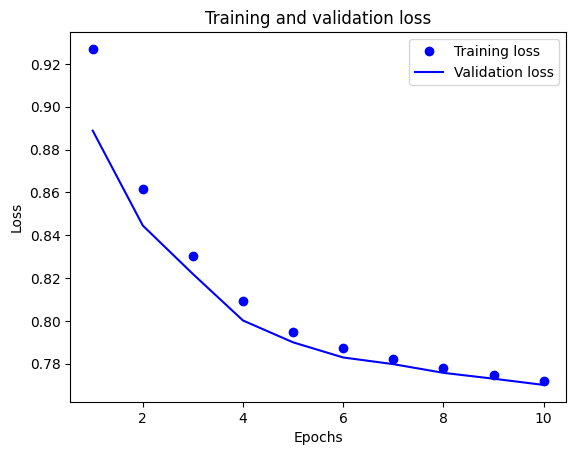

In [59]:
plot_loss_curves(history)

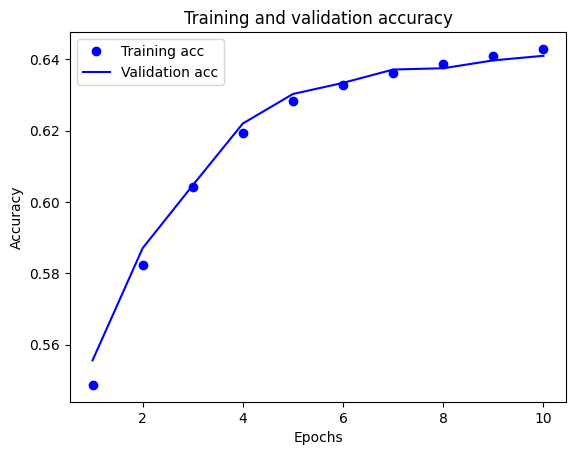

In [61]:
plot_acc_curves(history)

In [60]:
model.evaluate(x=X_test, y=y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6356 - loss: 0.7870


[0.7870206832885742, 0.6355745196342468]

In [62]:
embedding_layer = keras.layers.Embedding(
    max_tokens,
    embedding_dim,
    embeddings_initializer=keras.initializers.Constant(embedding_matrix),
    trainable=True, # note that this has changed from before!!
    mask_zero=True
)

inputs = keras.Input(shape=(max_length,))
embedded = embedding_layer(inputs)
embedded = keras.layers.GlobalAveragePooling1D()(embedded)
x = keras.layers.Dense(8, activation='relu')(embedded)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 100)  │    500,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 300)       │          0 │ input_layer_1[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 100)       │          0 │ embedding_1[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        808 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 8)         │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3)         │         27 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 500,835 (1.91 MB)

 Trainable params: 500,835 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])


In [74]:
# Fit model
history = model.fit(x=X_train, y=y_train,
                    validation_data=(X_val, y_val),
                    epochs=10,
                    batch_size=32,)

Epoch 1/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7328 - loss: 0.5705 - val_accuracy: 0.6976 - val_loss: 0.7995
Epoch 2/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7342 - loss: 0.5674 - val_accuracy: 0.6932 - val_loss: 0.8117
Epoch 3/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7344 - loss: 0.5676 - val_accuracy: 0.6922 - val_loss: 0.8255
Epoch 4/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7364 - loss: 0.5630 - val_accuracy: 0.6976 - val_loss: 0.8392
Epoch 5/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.7361 - loss: 0.5642 - val_accuracy: 0.6953 - val_loss: 0.8409
Epoch 6/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7358 - loss: 0.5641 - val_accuracy: 0.6952 - val_loss: 0.8422
Epoch 7/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7349 - loss: 0.5628 - val_accuracy: 0.6919 - val_loss: 0.8475
Epoch 8/10
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7373 - loss: 0.5600 - 

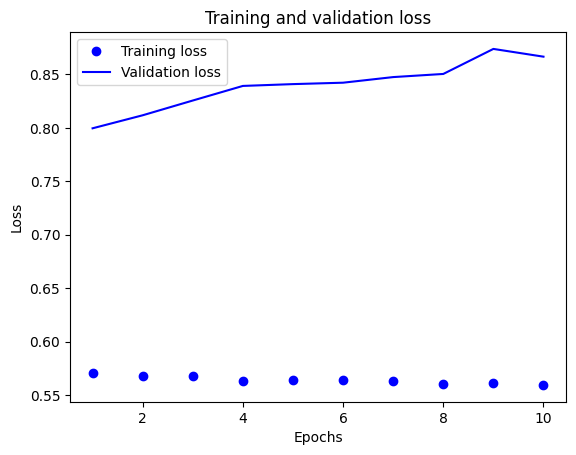

In [75]:
plot_loss_curves(history)

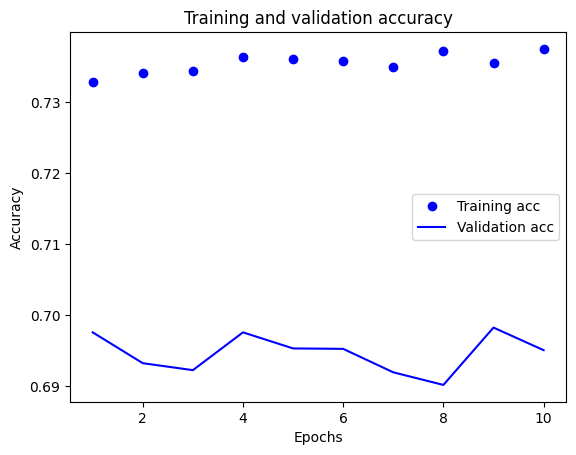

In [76]:
plot_acc_curves(history)

In [77]:
model.evaluate(x=X_test, y=y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6905 - loss: 0.8949


[0.894925594329834, 0.6904565095901489]

In [80]:
inputs = keras.Input(shape=(max_length,))

embedded = keras.layers.Embedding(input_dim=max_tokens,
                                  output_dim=64,
                                  mask_zero=True)(inputs)

embedded = keras.layers.GlobalAveragePooling1D()(embedded)

x = keras.layers.Dense(16, activation='relu')(embedded)

x = keras.layers.Dropout(0.5)(x)

outputs = keras.layers.Dense(3, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 300, 64)   │    320,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 300)       │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ embedding_4[0][0… │
│ (GlobalAveragePool… │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 16)        │      1,040 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 3)         │         51 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 321,091 (1.22 MB)

 Trainable params: 321,091 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(optimizer="adam",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

In [88]:
history = model.fit(x=X_train, y=y_train,
          validation_data=(X_val, y_val),
          epochs=8,
          batch_size=32,)

Epoch 1/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7621 - loss: 0.5257 - val_accuracy: 0.7011 - val_loss: 0.7436
Epoch 2/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7674 - loss: 0.5174 - val_accuracy: 0.6973 - val_loss: 0.7623
Epoch 3/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7685 - loss: 0.5154 - val_accuracy: 0.6979 - val_loss: 0.7801
Epoch 4/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7691 - loss: 0.5097 - val_accuracy: 0.7008 - val_loss: 0.7937
Epoch 5/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7720 - loss: 0.5011 - val_accuracy: 0.7013 - val_loss: 0.8249
Epoch 6/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7745 - loss: 0.4987 - val_accuracy: 0.7001 - val_loss: 0.8201
Epoch 7/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7767 - loss: 0.4957 - val_accuracy: 0.7012 - val_loss: 0.8536
Epoch 8/8
1531/1531 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7762 - loss: 0.4894 - val_accu

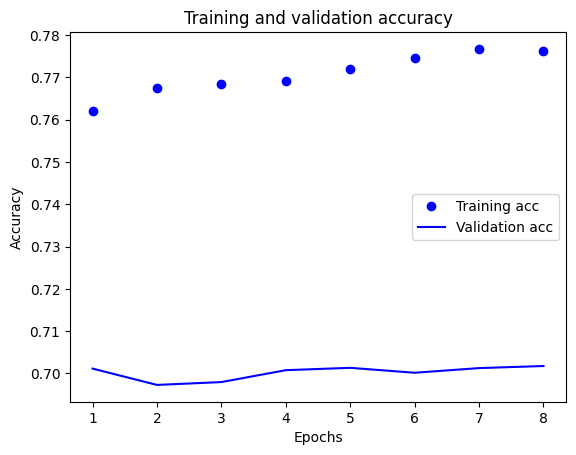

In [89]:
plot_acc_curves(history)

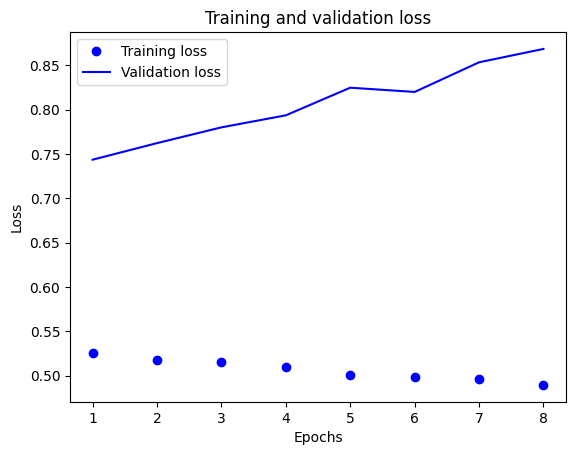

In [90]:
plot_loss_curves(history)

In [91]:
model.evaluate(x=X_test, y=y_test)

681/681 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7011 - loss: 0.8905


[0.8905285000801086, 0.7010654807090759]